In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from utilsforecast.plotting import plot_series as plot_series_utils
from scipy.stats import pearsonr
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
import os 
from plotnine import *
import calendar

# ETS packages
from statsforecast import StatsForecast
from statsforecast.models import AutoETS
from statsmodels.tsa.seasonal import seasonal_decompose
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import rmse, mae, mape, mase
from statsmodels.graphics.tsaplots import plot_acf

plt.style.use("ggplot")
import matplotlib as mpl
from cycler import cycler
mpl.rcParams['axes.prop_cycle'] = cycler(color=["#000000", "#000000"])
from fpppy.utils import plot_series

# change working directory 
# Check if current directory has any .ipynb files
if any(fname.endswith(".ipynb") for fname in os.listdir()):
    os.chdir("..")

# load local package modules
from gas_pump_prices.preprocess import * 

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Setup


Code below reads in historical gas prices and weekly CPI data. Data are then filered for unleaded gasoline prices in Toronto and prices are rebased to 2025 dollars using the following equation: 

$$
\text{Price}_{{2025 dollars}_t} = \frac{\text{CPI}_{2025}}{CPI_t} * \text{price}_t
$$

Note this correction needs to be improved because the CPI for gasoline reflects the volatility of gasoline prices and so yields unreasonable values when CPI values are high. As an example, in 2022, gas prices rose a bit above $2.00 but,when corrected for inflation using hte gasoline-specific CPI, the price in terms of 2025 dollars was $1.42 (which is just patently false). Therefore, a more stable CPI is needed that better reflects affordability of living conditions. The following options might be useful: 

1. All-items CPI
2. Core CPI (excluding food and energy)
3. Real wage/income comparisons 

In [8]:
df_gas = pd.read_csv('data/raw/fueltypesall.csv')

# convert date to datetime object 
df_gas['Date'] = pd.to_datetime(df_gas['Date'])
df_gas.drop('Type de carburant', axis=1, inplace=True)

# convert to long format 
df_gas = pd.melt(frame=df_gas, id_vars=['Date', 'Fuel Type'], 
        var_name='city',value_name='price')
df_gas = df_gas.query(
    "city == 'Toronto East/Est' &  `Fuel Type` == 'Regular Unleaded Gasoline'")

# read in inflation data
df_inflation = pd.read_csv('data/raw/1810000401_databaseLoadingData.csv')
df_inflation.columns = df_inflation.columns.str.lower()
df_gas_inf = df_inflation.query("`products and product groups` == 'All-items'").copy()
                                   
# compute dollars in terms of 2025 dollars
# 1) Compute CPIs centered on 2025
value_25 = df_gas_inf.query('ref_date == "2025-06"')['value']
df_gas_inf['cpi_2025'] = value_25.values/df_gas_inf['value']

# merge in CPI value based on year-month and compute 
df_gas['year_month'] = df_gas["Date"].dt.strftime("%Y-%m")
df_gas_inf["ref_date"] = pd.to_datetime(df_gas_inf["ref_date"])
df_gas_inf['date_ymw'] = df_gas_inf["ref_date"].dt.strftime("%Y-%m")

cols = ['date_ymw', 'value', 'cpi_2025']
df_gas = pd.merge(left=df_gas, right=df_gas_inf[cols],
                  left_on='year_month', right_on='date_ymw', how='left')


# NOTE: replace 1990-01 with 1990-02 and 2025-07 with 2025-06
df_gas.loc[df_gas['year_month'].eq("1990-01"), 'cpi_2025'] = df_gas.loc[df_gas['year_month'].eq("1990-02"), 'cpi_2025'].iloc[0]
df_gas.loc[df_gas['year_month'].eq("2025-07"), 'cpi_2025'] = df_gas.loc[df_gas['year_month'].eq("2025-06"), 'cpi_2025'].iloc[0]

assert (df_gas['cpi_2025'].isna().sum() == 0), '''Check missing cpi_2025 values'''

# compute price adjusted metrics 
df_gas['price_2025'] = df_gas['price'] * df_gas['cpi_2025']

assert (df_gas['price_2025'].isna().sum() == 0), '''Check missing price_2025 values'''

# create toronto data
df_toronto = df_gas.query("city == 'Toronto East/Est'" )
df_toronto.to_csv('data/processed/data_toronto_proc.csv', index=False)

# 1. Data exploration 

/opt/anaconda3/lib/python3.12/site-packages/mizani/breaks.py:448: FutureWarning: Passing the width as the parameter has been deprecated and will not work in a future version. Use breaks_date(width="4 years")


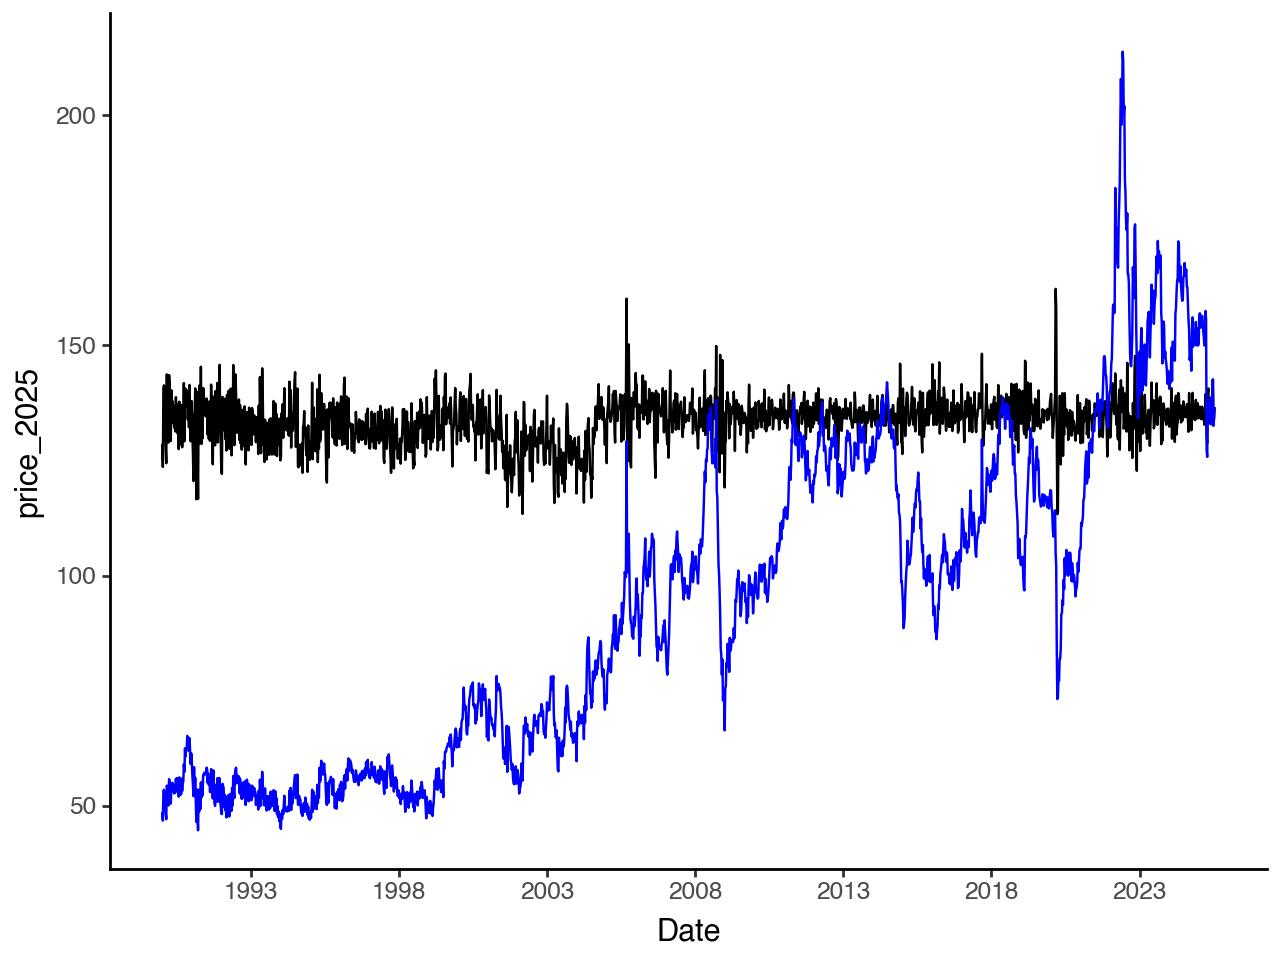

In [5]:
df_toronto = pd.read_csv('data/processed/data_toronto_proc.csv', index_col=False, parse_dates=['Date'])

(ggplot(data=df_toronto, mapping=aes(x='Date', y='price_2025')) + 
    geom_line() + 
    geom_line(mapping=aes(y='price'), color='blue') + 
    scale_x_datetime(date_breaks='5 years', date_labels='%Y') + 
    theme_classic())

In [ ]:
# initial examination of seasonal components (group by year and examine monthly average )
df_toronto['year'] = df_toronto['Date'].dt.year
df_toronto['month'] = df_toronto['Date'].dt.month
df_toronto['month_name'] = df_toronto['Date'].dt.strftime('%b')

df_month_avg =  (df_toronto.groupby(['year', 'month_name', 'month'])['price_2025'].mean().reset_index())

month_labels = {i: calendar.month_abbr[i] for i in range(1, 13)}

# NOTE: toronto gas price data doesn't have strong seasonality. 
(ggplot(data=df_month_avg.loc[df_month_avg['year'].ge(2005)], 
        mapping=aes(x='month', y='price_2025', group='factor(year)', color='factor(year)')) +
    geom_line() +
    scale_x_continuous(breaks=list(month_labels.keys()),
                       labels=list(month_labels.values())) +
    theme_classic())

# monthly averages; NOTE: little effect of seasonality
(df_toronto.groupby('month_name')['price_2025'].mean().reset_index())e

,month_name,price_2025
0,Apr,134.890833
1,Aug,136.186647
2,Dec,126.446865
3,Feb,128.519712
4,Jan,129.029553
5,Jul,137.034488
6,Jun,136.855890
7,Mar,130.903030
8,May,137.571403
9,Nov,129.961436


# 2. Baseline model 

A simple exponential smoothing (SES) model is determined as the best baseline model. 

$$
\begin{aligned}
\text{Forecast equation}: \hat{y}_{t+h|t} &= \ell_t \\ 
\text{Smoothing equation}: \ell_t &= \alpha y_t + (1-\alpha)\ell_{t-1}
\end{aligned}.
$$


In looking at the data, this makes sense given that, when adjusted for inflation, gas prices are actually very stable. Moreover, there is little seasonality in the data. 

In [7]:
"""
Compare following models using 10-fold cross-validation:

1) ETS(A,N,N); simple exponential smoothing model w/ additive error
2) ETS (A,A_d,N): Holt's linear method with damped trend (because gas prices 
actually remain constant when accounting for inflation)
3) ETS (A,A,A): Holt-Winters' additive method with seasonal component. The 
data don't appear to have strong seasonality 

Holt-Winters' model is the best reference model. 
"""
# create training and test sets
df_train = df_toronto.loc[df_toronto['Date'].lt('2021')]
df_test = df_toronto.loc[df_toronto['Date'].ge('2021')]
 
sf = StatsForecast(
    models=[AutoETS(season_length=52, model="ANN", alias="SES"), 
            AutoETS(season_length=52, model="AAN", alias="Holt"), 
            AutoETS(season_length=52, model="ANA", alias="error_season"), 
            AutoETS(season_length=52, model="AAA", alias="Holt_Winter")], freq="WE")

# 1. Use cross-validation  (10 sets with roling window size of 1 time period) 
# NOTE: use large step-size so that model can be evaluated in different seasons 
cols = ['Fuel Type', 'Date', 'price_2025']
forecast_int = 1
df_cv = sf.cross_validation(h=forecast_int, step_size=12, n_windows=20, 
                            df=df_train[cols], target_col='price_2025', 
                            time_col='Date', id_col='Fuel Type')

print("CV performance: \n", 
      evaluate(df=df_cv, metrics=[rmse, mae, mape], 
               models=['SES', 'Holt', 'error_season', 'Holt_Winter'], 
               target_col='price_2025', time_col='Date', id_col='Fuel Type'))

CV performance: 
                    Fuel Type metric       SES      Holt  error_season  \
0  Regular Unleaded Gasoline   rmse  3.905944  3.903829      3.652447   
1  Regular Unleaded Gasoline    mae  3.156196  3.154619      2.910605   
2  Regular Unleaded Gasoline   mape  0.023117  0.023106      0.021296   

   Holt_Winter  
0     3.616329  
1     2.944617  
2     0.021614  


In [ ]:
# NOTE: examine residuals by examining predictions that are made in consecutive prediction periods. 
# Only compare SES to Holt method 
cols = ['Fuel Type', 'Date', 'price_2025']
forecast_int = 1

df_res = sf.cross_validation(h=forecast_int, step_size=1, n_windows=26, 
                            df=df_train[cols], target_col='price_2025', 
                            time_col='Date', id_col='Fuel Type')

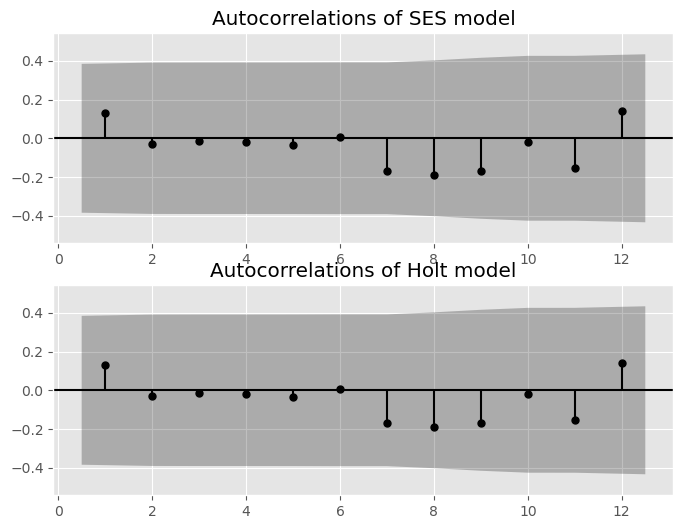

In [15]:
df_res['res_ses'] = (df_res['SES'] - df_res['price_2025'])
df_res['res_holt'] = (df_res['Holt'] - df_res['price_2025'])

fig, ax = plt.subplots(2, 1, figsize=(8, 6))

# examine ACF plot 
plot_acf(x=df_res['res_ses'], lags=12,
         ax=ax[0],
         zero=False, bartlett_confint=True, auto_ylims=True,
         title="Autocorrelations of SES model")

plot_acf(x=df_res['res_holt'], lags=12,
         ax=ax[1],
         zero=False, bartlett_confint=True, auto_ylims=True,
         title="Autocorrelations of Holt model")

# 3. Model fitting 


Fit the following models: 

1. Time series regression model
2.. ARIMA model 
3. Dynamic regression model

Questions

1. Does a random-forest model of TS models (i.e., weak learners) produce less biased model with lower variance? 
2. How to handle patterns of multiple seasonality (weekly, seasons, holidays)? 
3. How to handle feedback effects of current gas prices on future ones? That is, when gas prices become too high
the rate of production slows down. 
4. 


## 3.1. Brainstorming/research factors affecting gas prices

From https://www.bankofcanada.ca/2024/06/what-you-pay-for-at-the-pump/

Four important factor affecting gas prices: 

1. 40% = Cost of crude oil 
2. 20% = Refinement of oil into gas
3. 35% = Taxes
4. 5% = Marketing


1. Test out predictive power of model that includes important geoplotical events (e.g., Russia-Ukraine war)